In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers = pd.read_csv(
    "../03_cleaned_data/customers_cleaned.csv",
    parse_dates=["First order date", "Last purchase date"]
)

orders = pd.read_csv(
    "../03_cleaned_data/orders_cleaned.csv",
    parse_dates=["Order date & time"]
)

order_items = pd.read_csv(
    "../03_cleaned_data/order_line_items_cleaned.csv"
)

sku_catalog = pd.read_csv(
    "../03_cleaned_data/sku_catalog_cleaned.csv"
)

website_sessions = pd.read_csv(
    "../03_cleaned_data/website_sessions_cleaned.csv",
    parse_dates=["date"]
)

### monthly revenue


In [3]:
print(orders.columns.tolist())

['Order ID', 'Customer ID', 'Order date & time', 'Product', 'Order value (gross)', 'Order value (net)', 'Discount applied (₹)', 'Discount applied (%)', 'Payment mode', 'Shipping city', 'Pincode', 'First order vs repeat', 'Channel source (last touch)', 'Delivered / Returned / RTO', 'order_rank', 'Corrected order type']


In [4]:
orders['months'] = orders['Order date & time'].dt.to_period('M')

In [5]:
monthly_revenue = orders.groupby(orders['months'])['Order value (gross)'].sum()
monthly_revenue.index = monthly_revenue.index.to_timestamp()

In [6]:
print(orders['Order date & time'].dtype)

datetime64[ns]


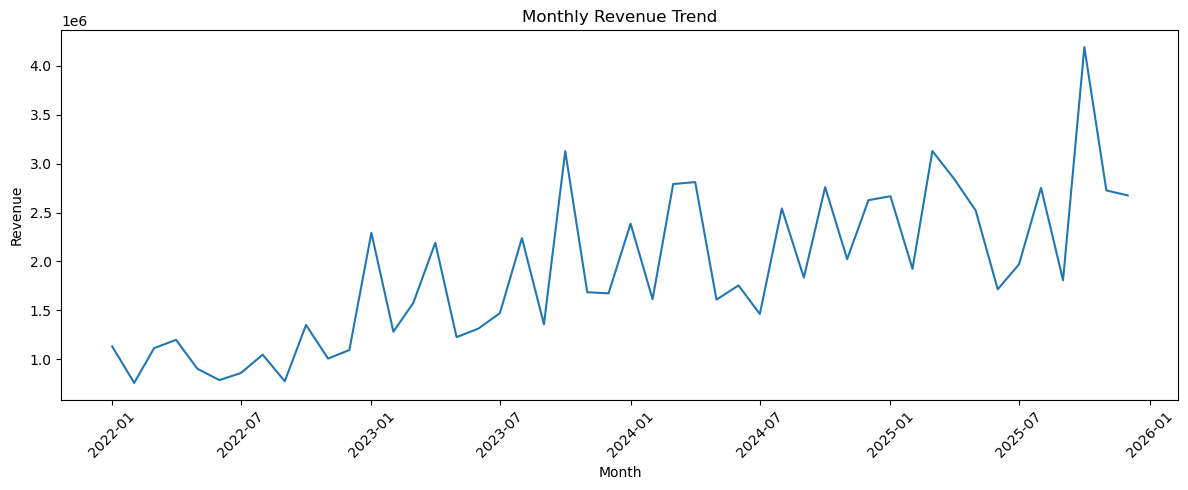

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### *Yearly Revenue*

In [8]:
orders['year'] = orders['Order date & time'].dt.year

yearly_revenue = orders.groupby('year')['Order value (gross)'].sum()
print(yearly_revenue)

year
2022    12024020
2023    21437423
2024    26217870
2025    30919500
Name: Order value (gross), dtype: int64


In [9]:
orders["year"]=orders["Order date & time"].dt.year

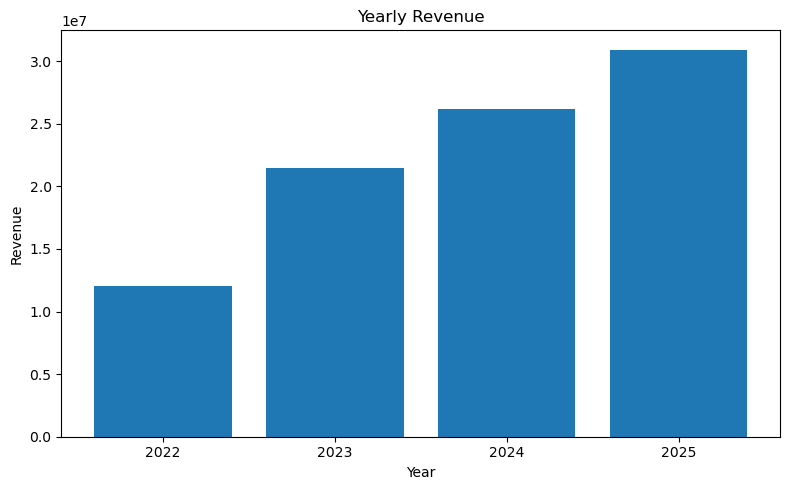

In [10]:
plt.figure(figsize=(8, 5))

plt.bar(
    yearly_revenue.index.astype(str),
    yearly_revenue.values
)

plt.title("Yearly Revenue")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

### Revenue by category

In [11]:
category_revenue = (
    order_items.groupby(
        "Category (top, bottom, outerwear, etc.)"
    )["Selling price"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

Category (top, bottom, outerwear, etc.)
shirts      33695543
pants       19112182
croptops    10339595
tshirts      8366221
shorts       3375633
jackets      2949295
Name: Selling price, dtype: int64

In [12]:
yearly_revenue=(orders.groupby("year")["Order value (net)"].sum())
yearly_revenue

year
2022    10007245
2023    17999988
2024    21999990
2025    25999954
Name: Order value (net), dtype: int64

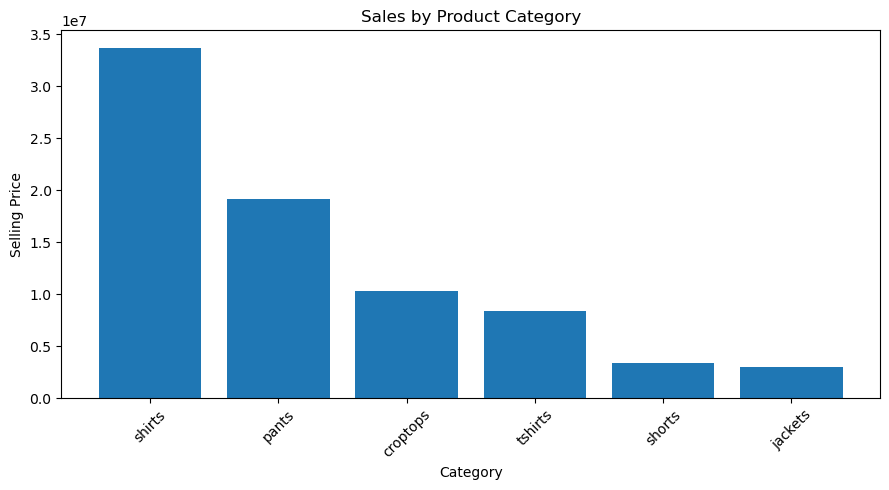

In [13]:
plt.figure(figsize=(9, 5))

plt.bar(
    category_revenue.index,
    category_revenue.values
)

plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Selling Price")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Average Order Value

In [14]:
monthly_aov = (
    orders.groupby("months")["Order value (net)"]
    .agg(["sum", "count"])
)

In [15]:
monthly_aov["AOV"] = (
    monthly_aov["sum"] /
    monthly_aov["count"]
)

In [16]:
monthly_aov.head()

,sum,count,AOV
months,,,
2022-01,910585,519,1754.499037
2022-02,660991,380,1739.450000
2022-03,898899,508,1769.486220
2022-04,968182,554,1747.620939
2022-05,785495,442,1777.138009


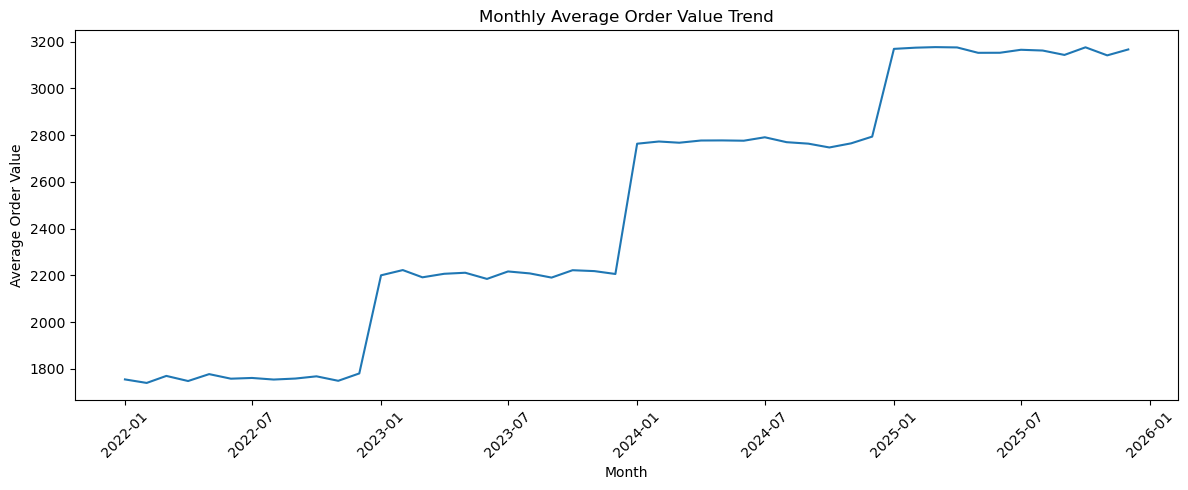

In [17]:
monthly_aov.index = monthly_aov.index.to_timestamp()
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_aov.index,
    monthly_aov["AOV"]
)
plt.title("Monthly Average Order Value Trend")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 2. Geographic & Payment Patterns

### Business questions:
Which cities generate the most revenue?
Is revenue concentrated in particular cities?
Which city tiers have the highest revenue?
Do higher-tier cities have higher AOV?
Which payment methods are most commonly used?
Does COD still dominate or is UPI more common?

In [18]:
city_revenue=(orders.groupby('Shipping city')['Order value (net)'].sum().sort_values(ascending=False))

In [19]:
top_10_cities=city_revenue.head()

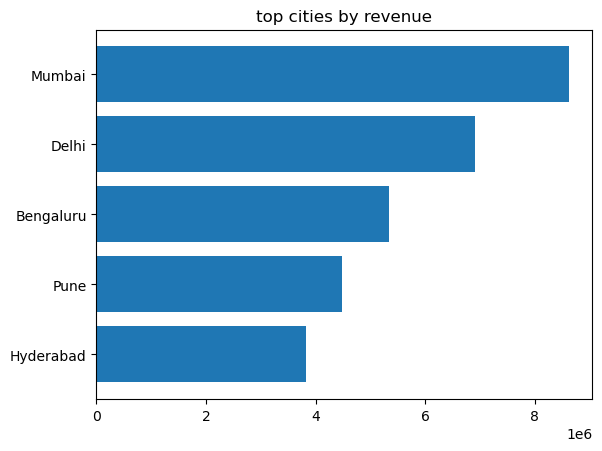

In [20]:
plt.barh(top_10_cities.index,
        top_10_cities.values)
plt.title("top cities by revenue")
plt.gca().invert_yaxis()
plt.show()

In [21]:
customer_city=(customers.groupby('city')['Customer ID'].nunique().sort_values(ascending=False))

In [22]:
top_city_cust=customer_city.head(10)

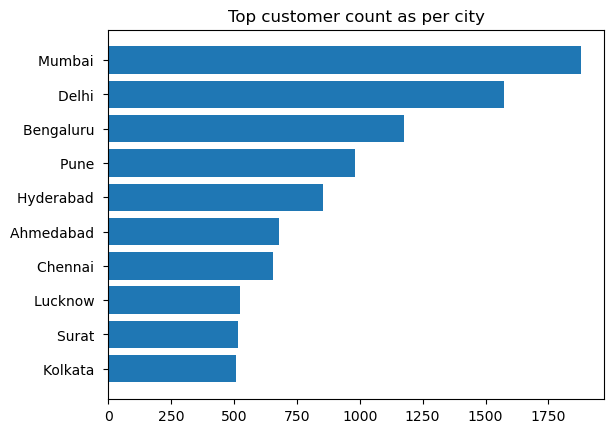

In [23]:
plt.barh(top_city_cust.index,top_city_cust.values)
plt.title("Top customer count as per city")
plt.gca().invert_yaxis()
plt.show()

In [24]:
orders_city=orders.merge(customers[['Customer ID','city']],on='Customer ID',how='left')

In [25]:
aov_by_city=(orders_city.groupby('city')['Order value (net)'].mean().sort_values(ascending=False))

In [26]:
top_10_aov_city=aov_by_city.head(5)
top_10_aov_city

city
Ranchi       2584.010101
Lucknow      2569.393593
Patna        2557.529674
Rajkot       2557.119424
Ludhiana     2552.866779
Name: Order value (net), dtype: float64

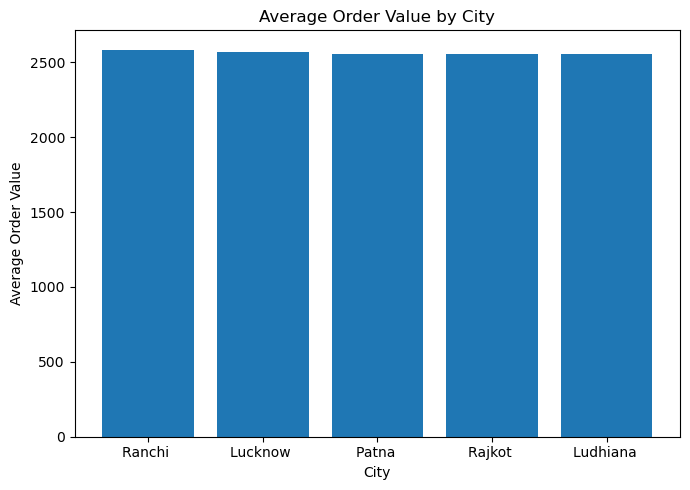

In [27]:
plt.figure(figsize=(7, 5))

plt.bar(
    top_10_aov_city.index,
    top_10_aov_city.values
)

plt.title("Average Order Value by City")
plt.xlabel("City")
plt.ylabel("Average Order Value")

plt.tight_layout()
plt.show()

In [28]:
customers.head()

,Customer ID,Name,First order date,Total orders,Total revenue,Average order value,Time to 2nd purchase,Last purchase date,Acquisition channel (first touch),RePurchased,city,tier
0,CUST-0000001,Tejas Sarkar,2025-09-08,1,3356,3356.0,NaN,2025-09-08,Meta,N,Mumbai,Tier 1
1,CUST-0000003,Lila Bedi,2023-09-11,1,2360,2360.0,NaN,2023-09-11,Google,N,Bengaluru,Tier 1
2,CUST-0000004,Hamsini Parekh,2022-03-18,2,4029,2014.5,449.0,2023-06-11,Google,Y,Hyderabad,Tier 1
3,CUST-0000005,Yug Gill,2025-10-16,1,2581,2581.0,NaN,2025-10-16,Offline (Friends/Family),N,Delhi,Tier 1
4,CUST-0000007,Daksha Ramaswamy,2024-03-11,2,5365,2682.5,303.0,2025-01-08,Meta,Y,Bengaluru,Tier 1


In [29]:
payment_orders = (
    orders["Payment mode"]
    .value_counts())
payment_orders

Payment mode
UPI           11306
Card           9586
COD            5473
NetBanking     1828
Wallet         1807
Name: count, dtype: int64

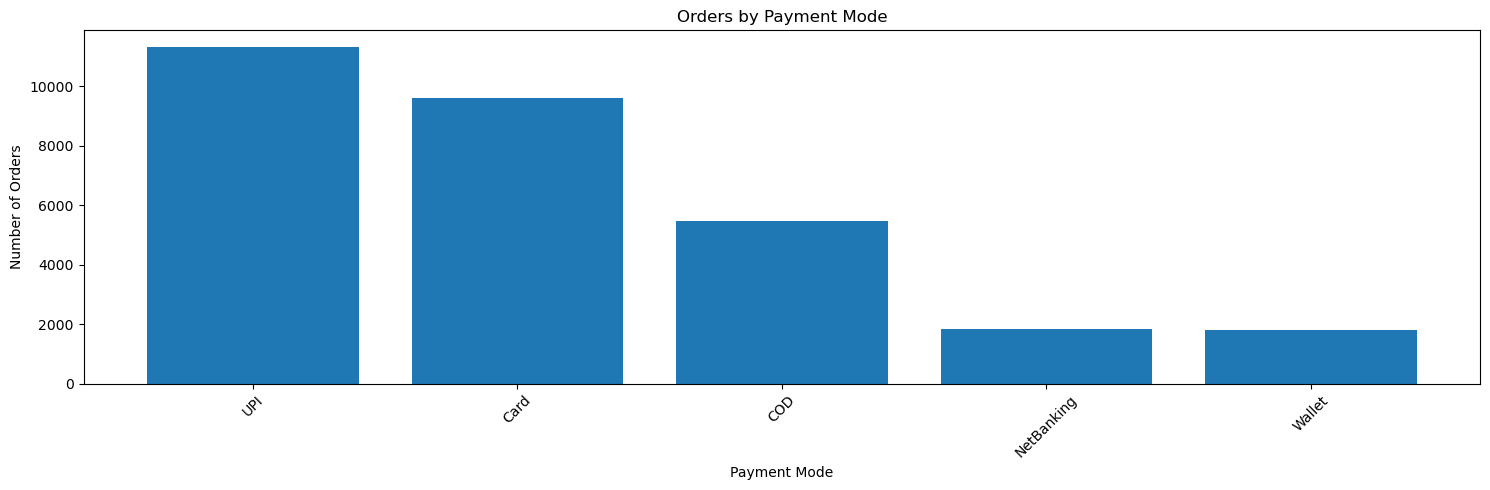

In [30]:
plt.figure(figsize=(15, 5))

plt.bar(
    payment_orders.index,
    payment_orders.values
)

plt.title("Orders by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
payment_revenue = (
    orders.groupby("Payment mode")["Order value (net)"]
    .sum()
    .sort_values(ascending=False)
)

payment_revenue

Payment mode
UPI           28746461
Card          24194137
COD           13851896
NetBanking     4645341
Wallet         4569342
Name: Order value (net), dtype: int64

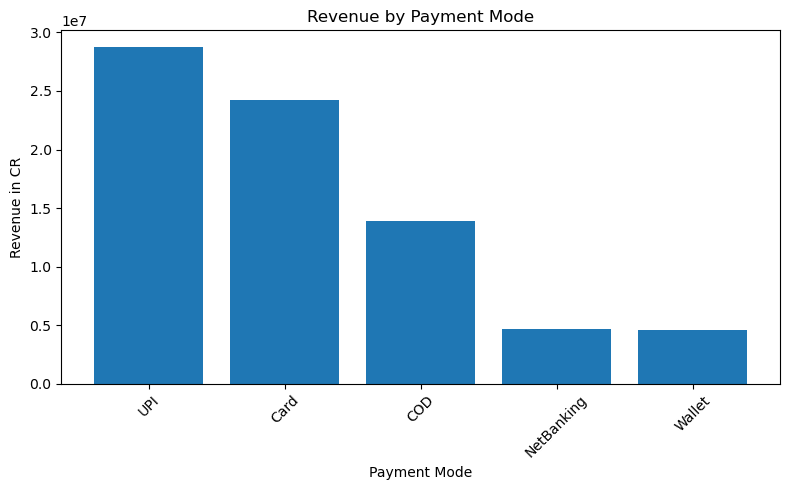

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(
    payment_revenue.index,
    payment_revenue.values
)

plt.title("Revenue by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Revenue in CR")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Customer Retention Behavior

### Business questions:
What % of customers are repeat buyers vs one-time buyers?
What's the average time gap between a customer's 1st and 2nd order?
Does repeat-purchase rate vary by acquisition channel or product category?
What's the revenue contribution of repeat customers vs new customers

# 1 - What % of customers are repeat buyers vs one-time buyers?

,Order ID,Customer ID,Order date & time,Product,Order value (gross),Order value (net),Discount applied (₹),Discount applied (%),Payment mode,Shipping city,Pincode,First order vs repeat,Channel source (last touch),Delivered / Returned / RTO,order_rank,Corrected order type,months,year
0,ORD-20220101-000001,CUST-0001627,2022-01-01 20:18:00,2-item cart,2339,1814,525,22.5,Card,Lucknow,624797,First,Meta,Delivered,1.0,First,2022-01,2022
1,ORD-20220101-000002,CUST-0006543,2022-01-01 23:42:00,2-item cart,2588,1812,777,30.0,UPI,Delhi,779192,First,Meta,Delivered,1.0,First,2022-01,2022
2,ORD-20220101-000003,CUST-0021661,2022-01-01 22:25:00,2-item cart,2546,2210,336,13.2,UPI,Chandigarh,516352,First,Organic Instagram,Delivered,1.0,First,2022-01,2022
3,ORD-20220101-000004,CUST-0007414,2022-01-01 10:16:00,2-item cart,1800,1395,405,22.5,COD,Indore,268472,First,Influencer,RTO,1.0,First,2022-01,2022
4,ORD-20220101-000005,CUST-0019325,2022-01-01 22:34:00,2-item cart,2155,1853,302,14.0,UPI,Mumbai,515911,First,Meta,Delivered,1.0,First,2022-01,2022


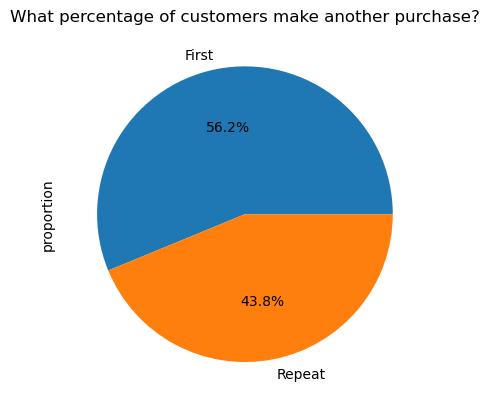

In [33]:
repurchased_pct=(orders['Corrected order type'].value_counts(normalize=True).mul(100).plot(kind="pie",autopct="%1.1f%%"),
                plt.title("What percentage of customers make another purchase?"))

In [34]:
customers

,Customer ID,Name,First order date,Total orders,Total revenue,Average order value,Time to 2nd purchase,Last purchase date,Acquisition channel (first touch),RePurchased,city,tier
0,CUST-0000001,Tejas Sarkar,2025-09-08,1,3356,3356.00,NaN,2025-09-08,Meta,N,Mumbai,Tier 1
1,CUST-0000003,Lila Bedi,2023-09-11,1,2360,2360.00,NaN,2023-09-11,Google,N,Bengaluru,Tier 1
2,CUST-0000004,Hamsini Parekh,2022-03-18,2,4029,2014.50,449.0,2023-06-11,Google,Y,Hyderabad,Tier 1
3,CUST-0000005,Yug Gill,2025-10-16,1,2581,2581.00,NaN,2025-10-16,Offline (Friends/Family),N,Delhi,Tier 1
4,CUST-0000007,Daksha Ramaswamy,2024-03-11,2,5365,2682.50,303.0,2025-01-08,Meta,Y,Bengaluru,Tier 1
...,...,...,...,...,...,...,...,...,...,...,...,...
16860,CUST-0026992,Janani Wagle,2022-01-21,4,9179,2294.75,475.0,2025-08-05,Meta,Y,Pune,Tier 1
16861,CUST-0026996,Lajita Chand,2022-11-07,3,7064,2354.67,292.0,2024-02-29,Influencer,Y,Hyderabad,Tier 1
16862,CUST-0026997,Vihaan Sundaram,2023-03-21,4,10087,2521.75,326.0,2024-04-20,Influencer,Y,Vadodara,Tier 2
16863,CUST-0026999,Charvi Singhal,2022-02-05,1,1606,1606.00,NaN,2022-02-05,Email/SMS,N,Bhopal,Tier 2


# 2- What's the average time gap between a customer's 1st and 2nd order? 

In [35]:
customers['Time to 2nd purchase'].describe()

count    7748.000000
mean      410.219928
std       315.313487
min         0.000000
25%       152.000000
50%       342.000000
75%       606.000000
max      1452.000000
Name: Time to 2nd purchase, dtype: float64

In [36]:
customers[customers['RePurchased']=='Y']['Time to 2nd purchase'].median()

342.0

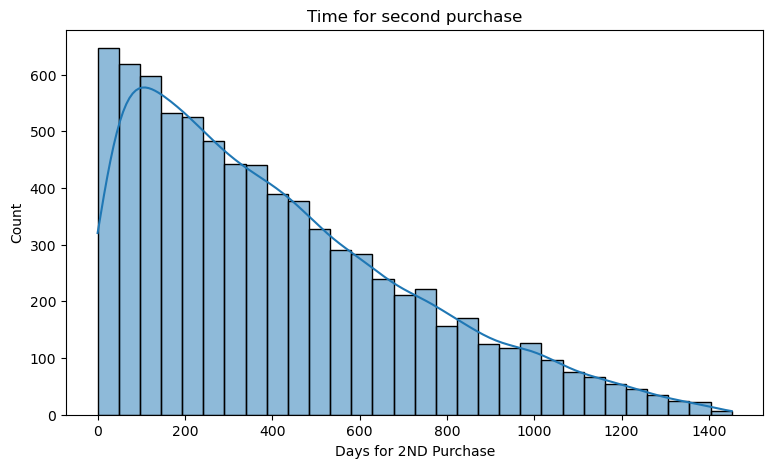

In [37]:
plt.figure(figsize=(9,5))
sns.histplot(customers.loc[customers['RePurchased']=='Y','Time to 2nd purchase'],bins=30,kde=True)
plt.title("Time for second purchase")
plt.xlabel("Days for 2ND Purchase")
plt.show()

# 3- Does repeat-purchase rate vary by acquisition channel or product category?

In [38]:
retention_channel=(customers.groupby('Acquisition channel (first touch)')["RePurchased"]
    .apply(lambda x: (x=="Y").mean()*100)
    .sort_values(ascending=False))

In [39]:
retention_channel

Acquisition channel (first touch)
Email/SMS                   48.761062
Organic Instagram           48.035285
Offline (Friends/Family)    47.820966
Instagram DM                46.473988
Meta                        45.586424
Influencer                  45.518259
Google                      44.448476
Name: RePurchased, dtype: float64

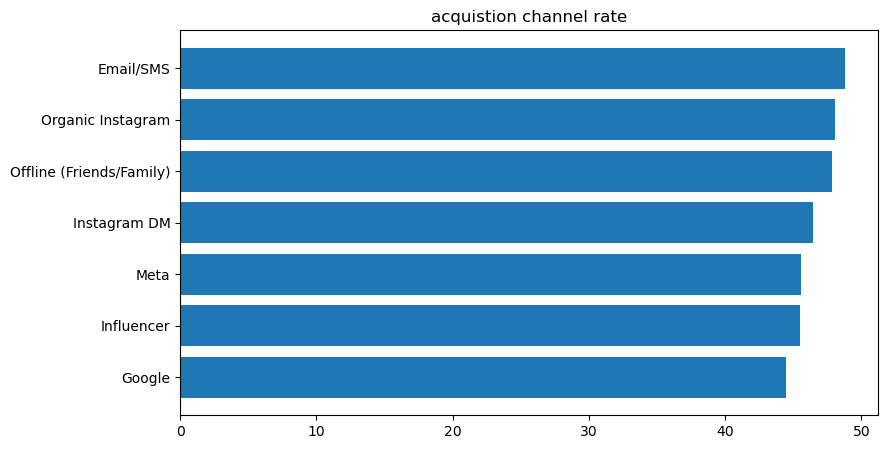

In [40]:
plt.figure(figsize=(9,5))
plt.barh(retention_channel.index,
       retention_channel.values)
plt.gca().invert_yaxis()
plt.title('acquistion channel rate')
plt.show()

In [41]:
customers = pd.read_csv(
    "../03_cleaned_data/customers_cleaned.csv",
    parse_dates=["First order date", "Last purchase date"]
)


# 4- What's the revenue contribution of repeat customers vs new customers

In [42]:
revenue_by_type = (customers.groupby("RePurchased")["Total revenue"].sum())

In [43]:
revenue_by_type

RePurchased
N    22986827
Y    53020350
Name: Total revenue, dtype: int64

In [44]:
revenue_pct =(revenue_by_type/revenue_by_type.sum()*100).round(1)

In [45]:
revenue_pct

RePurchased
N    30.2
Y    69.8
Name: Total revenue, dtype: float64

In [46]:
customer_split = customers['RePurchased'].value_counts(normalize=True) * 100
print(customer_split)

RePurchased
N    54.058701
Y    45.941299
Name: proportion, dtype: float64


In [47]:
print(customers.shape[0])
print(customers['Customer ID'].nunique())

16865
16865


In [48]:
comparision = pd.DataFrame({"customer %" : customer_split,"revenue %": revenue_pct })
comparision

,customer %,revenue %
RePurchased,,
N,54.058701,30.2
Y,45.941299,69.8


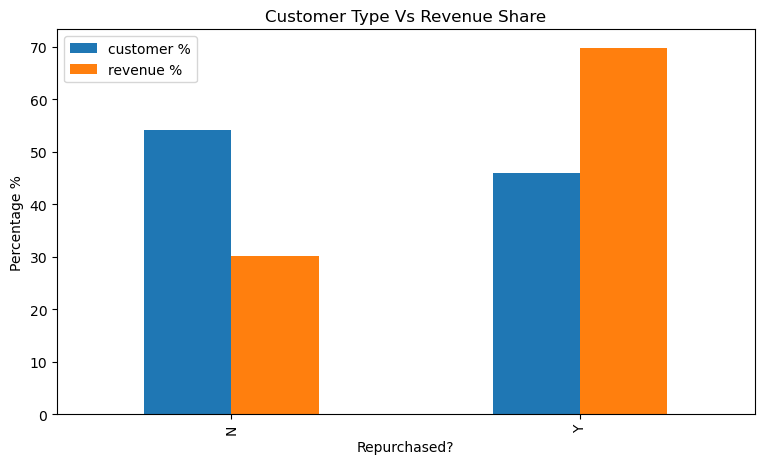

In [49]:
comparision.plot(kind='bar',figsize=(9,5))
plt.xlabel('Repurchased?')
plt.ylabel('Percentage %')
plt.title("Customer Type Vs Revenue Share")
plt.show()

In [50]:
website_sessions.sample(10)

,session_id,date,traffic_source,campaign_name,device_category,city,sessions,product_views,add_to_cart,begin_checkout,purchased,order_id,customer_id,revenue,is_converted
374154,SESS-20250311-EM-MO-801733,2025-03-11,Email/SMS,NaN,mobile,Jaipur,1,3,0,0,0,NaN,NaN,0,False
147281,SESS-20230516-GO-MO-139287,2023-05-16,Google,NaN,mobile,Surat,1,5,0,0,0,NaN,NaN,0,False
250143,SESS-20240314-IN-MO-239045,2024-03-14,Influencer,NaN,mobile,Ahmedabad,1,5,0,0,0,NaN,NaN,0,False
238784,SESS-20240207-GO-MO-697656,2024-02-07,Google,NaN,mobile,Mumbai,1,0,0,0,0,NaN,NaN,0,False
274737,SESS-20240524-GO-MO-143015,2024-05-24,Google,NaN,mobile,Ahmedabad,1,5,0,0,0,NaN,NaN,0,False
473750,SESS-20251226-GO-TA-158499,2025-12-26,Google,NaN,tablet,Delhi,1,3,0,0,0,NaN,NaN,0,False
291597,SESS-20240721-GO-MO-540540,2024-07-21,Google,NaN,mobile,Bengaluru,1,1,0,0,0,NaN,NaN,0,False
364049,SESS-20250207-EM-MO-230320,2025-02-07,Email/SMS,NaN,mobile,Delhi,1,2,0,0,0,NaN,NaN,0,False
167781,SESS-20230726-ME-MO-145063,2023-07-26,Meta,KS_Jul23_Camp_14,mobile,Surat,1,2,1,1,1,ORD-20230726-009947,CUST-0017795,2210,True
92245,SESS-20221204-ME-MO-667860,2022-12-04,Meta,KS_AlwaysOn,mobile,Jaipur,1,1,0,0,0,NaN,NaN,0,False


# 4. Marketing Channel & Funnel Effectiveness
Which marketing channel drives the most website sessions?
Which channel has the best session-to-purchase conversion rate (using your is_converted column)?
Where's the biggest drop-off in the funnel (sessions → cart → purchase, if that data exists)?
Which channel brings in customers with the highest AOV or highest repeat rate? (connects Section 3 to Section 2 — good BI thinking)

## Which marketing channel drives the most website sessions?

In [51]:
most_sessions = (website_sessions.groupby("traffic_source")["sessions"].sum().sort_values(ascending=False))

<Axes: xlabel='traffic_source'>

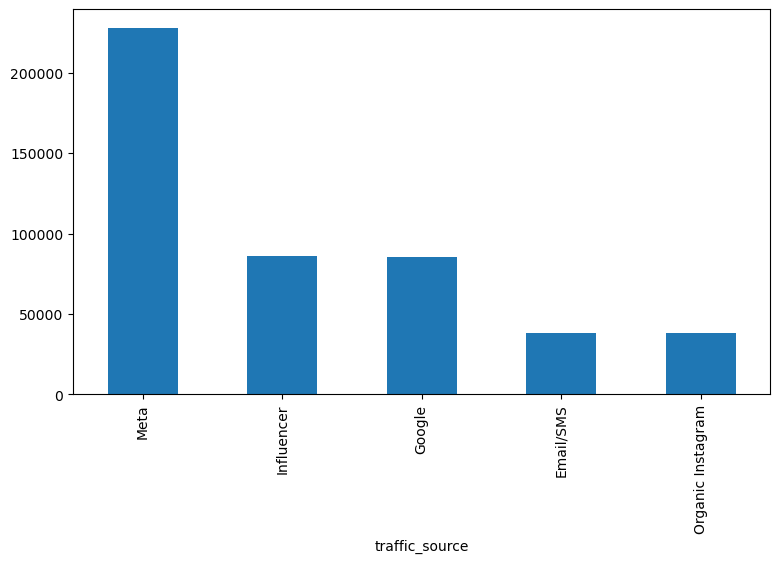

In [52]:
most_sessions.plot(kind="bar",figsize=(9,5))

## Which channel has the best session-to-purchase conversion rate? 

In [53]:
conversion_channel = (
    website_sessions
    .groupby("traffic_source")
    .agg(
        total_sessions=("sessions", "sum"),
        converted_sessions=("is_converted", "sum")
    )
)

conversion_channel

,total_sessions,converted_sessions
traffic_source,,
Email/SMS,38164,2066
Google,85288,4912
Influencer,85937,4850
Meta,228190,12936
Organic Instagram,38077,0


In [54]:
conversion_channel["conversion_rate"] = (
    conversion_channel["converted_sessions"]
    / conversion_channel["total_sessions"]
    * 100
)

In [55]:
conversion_channel = conversion_channel.sort_values(
    "conversion_rate",
    ascending=False
)

conversion_channel

,total_sessions,converted_sessions,conversion_rate
traffic_source,,,
Google,85288,4912,5.759310
Meta,228190,12936,5.668960
Influencer,85937,4850,5.643669
Email/SMS,38164,2066,5.413479
Organic Instagram,38077,0,0.000000


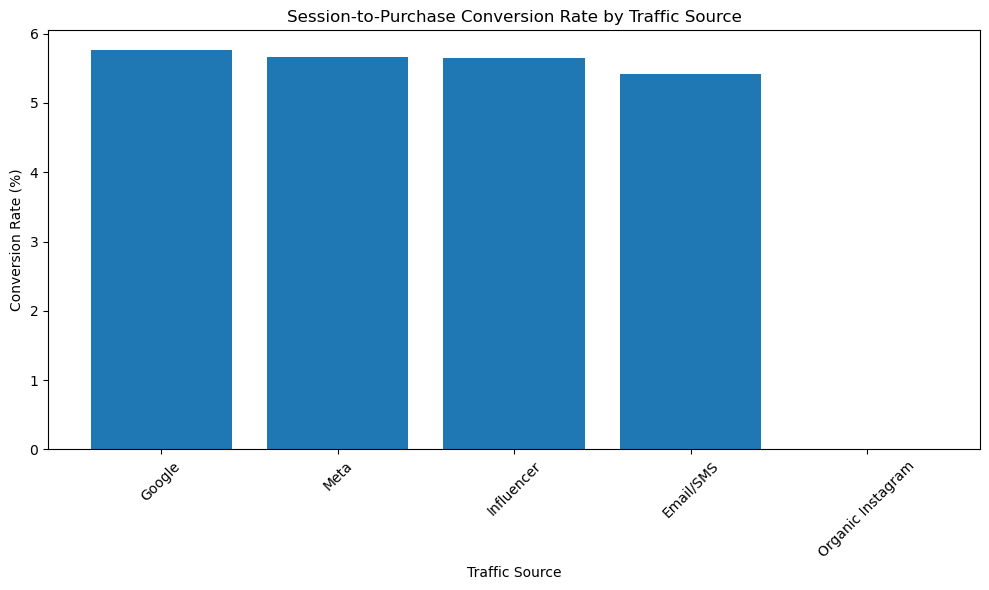

In [56]:
plt.figure(figsize=(10, 6))

plt.bar(
    conversion_channel.index,
    conversion_channel["conversion_rate"]
)

plt.title("Session-to-Purchase Conversion Rate by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Where's the biggest drop-off in the funnel?

In [57]:
funnel_totals = website_sessions[['sessions', 'product_views', 'add_to_cart', 'begin_checkout', 'purchased']].sum()
print(funnel_totals)

sessions           475656
product_views     1521604
add_to_cart         64708
begin_checkout      49048
purchased           29983
dtype: int64


In [58]:
stages = ['sessions', 'product_views', 'add_to_cart', 'begin_checkout', 'purchased']
dropoff = []

for i in range(len(stages) - 1):
    current = funnel_totals[stages[i]]
    next_stage = funnel_totals[stages[i+1]]
    drop_pct = ((current - next_stage) / current * 100).round(1)
    dropoff.append({'from': stages[i], 'to': stages[i+1], 'drop_pct': drop_pct})

dropoff_df = pd.DataFrame(dropoff)
print(dropoff_df)

             from              to  drop_pct
0        sessions   product_views    -219.9
1   product_views     add_to_cart      95.7
2     add_to_cart  begin_checkout      24.2
3  begin_checkout       purchased      38.9


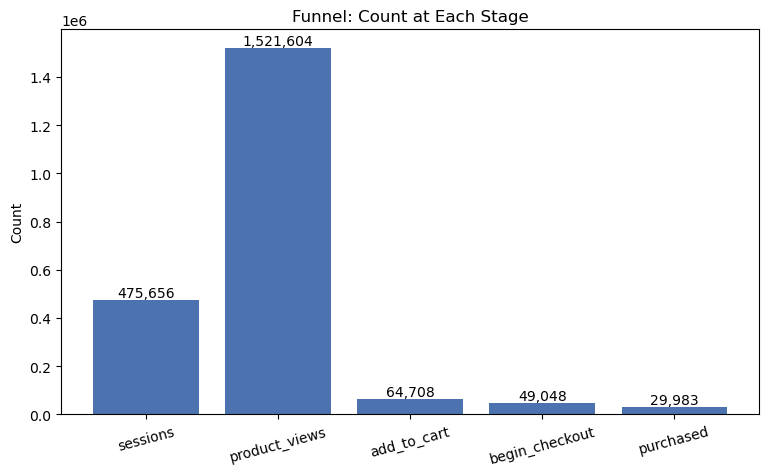

In [59]:
plt.figure(figsize=(9,5))
plt.bar(stages, funnel_totals.values, color='#4C72B0')
plt.title('Funnel: Count at Each Stage')
plt.ylabel('Count')
plt.xticks(rotation=15)

# Add value labels on top of each bar
for i, v in enumerate(funnel_totals.values):
    plt.text(i, v, f'{int(v):,}', ha='center', va='bottom')

plt.show()

## Which channel brings in customers with the highest AOV or highest repeat rate?

In [60]:
aov_by_channel = customers.groupby('Acquisition channel (first touch)')['Average order value'].mean().round(0).sort_values(ascending=False)
print(aov_by_channel)

Acquisition channel (first touch)
Instagram DM                2557.0
Google                      2544.0
Influencer                  2526.0
Meta                        2523.0
Email/SMS                   2521.0
Organic Instagram           2520.0
Offline (Friends/Family)    2518.0
Name: Average order value, dtype: float64


In [61]:
repeat_by_channel = customers.groupby('Acquisition channel (first touch)')['RePurchased'].apply(
    lambda x: (x == 'Y').mean() * 100
).round(1).sort_values(ascending=False)
print(repeat_by_channel)

Acquisition channel (first touch)
Email/SMS                   48.8
Organic Instagram           48.0
Offline (Friends/Family)    47.8
Instagram DM                46.5
Meta                        45.6
Influencer                  45.5
Google                      44.4
Name: RePurchased, dtype: float64


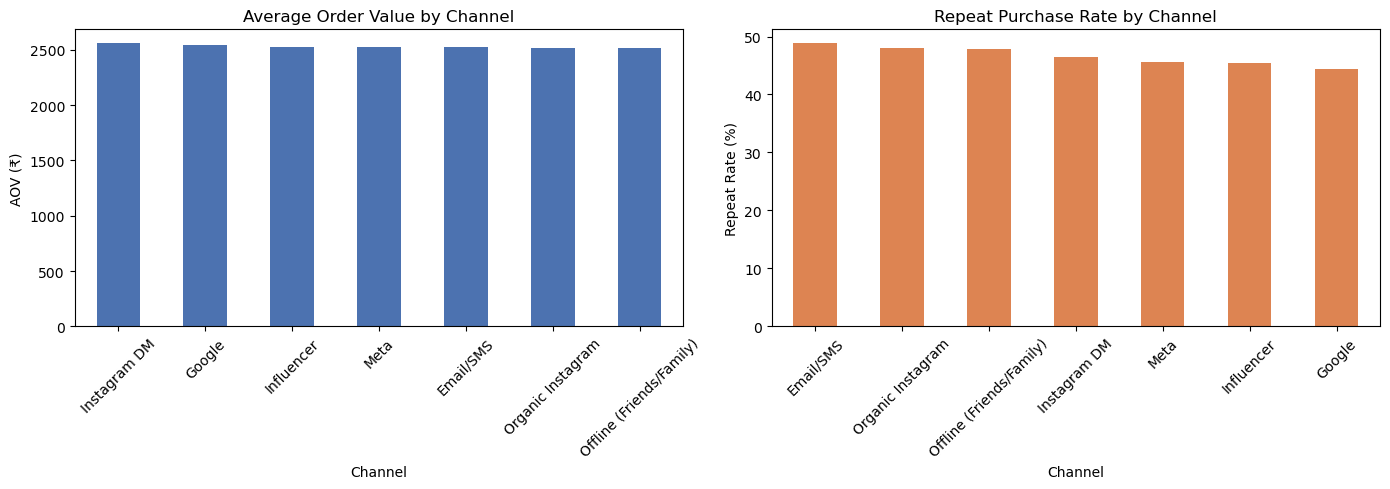

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

aov_by_channel.plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Average Order Value by Channel')
axes[0].set_ylabel('AOV (₹)')
axes[0].set_xlabel('Channel')
axes[0].tick_params(axis='x', rotation=45)

repeat_by_channel.plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Repeat Purchase Rate by Channel')
axes[1].set_ylabel('Repeat Rate (%)')
axes[1].set_xlabel('Channel')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### is the channel with the highest sessions is actually the same channel driving the highest AOV/repeat rate here? Often the answer is no — a channel like paid social might bring high volume but low-value, low-loyalty customers, while something like organic/referral brings fewer but much more valuable customers

In [64]:
%whos DataFrame

Variable             Type         Data/Info
-------------------------------------------
comparision          DataFrame    Shape: (2, 2)
conversion_channel   DataFrame    Shape: (5, 3)
customers            DataFrame    Shape: (16865, 12)
dropoff_df           DataFrame    Shape: (4, 3)
monthly_aov          DataFrame    Shape: (48, 3)
order_items          DataFrame    Shape: (42108, 11)
orders               DataFrame    Shape: (30000, 18)
orders_city          DataFrame    Shape: (30000, 19)
sku_catalog          DataFrame    Shape: (55, 5)
website_sessions     DataFrame    Shape: (475656, 15)
